# GSE60450 (Fu 2015 mouse mammary): R limma vs pylimma parity

This notebook runs the pylimma `voom` pipeline live on the Fu et al. 2015 mouse mammary RNA-seq dataset and compares the output against pre-computed R limma results.

**Dataset**: 27,179 Entrez-gene-level counts x 12 samples. Contrast: basal vs luminal cells, collapsing developmental stages. Raw counts are fed to `voom` in both runtimes so the mean-variance modelling is part of the parity check.

**Pipeline**: `voom` -> `lm_fit` -> `contrasts_fit` -> `e_bayes` -> `top_table`

**R reference**: the CSV in `data/R_references/gse60450_toptable.csv.gz` was produced once by `data/_setup_R_references.R` on R 4.2.3 with limma 3.54.2. The `VERSIONS.txt` sidecar records the exact toolchain.

The notebook loads both the dataset and the R reference from the committed CSVs. No R installation is required to run it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add the repository root to sys.path so `pylimma` and the
# `data/generate_data.py` helper are importable when running
# this notebook directly from `examples/`.
REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "data"))

import generate_data as gd

import pylimma

DATA_DIR = REPO / "data"
R_REF    = DATA_DIR / "R_references"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 10)

## 1. Load the data and the R reference

In [2]:
data = gd.load_gse60450()
counts  = data["counts"]
targets = data["targets"]
print(f"counts matrix: {counts.shape}")
print(targets)

r_ref = pd.read_csv(R_REF / "gse60450_toptable.csv.gz")
r_ref["GeneID"] = r_ref["GeneID"].astype(str)
r_ref = r_ref.set_index("GeneID")
print(f"\nR reference top-table: {r_ref.shape}")
r_ref.head()

counts matrix: (27179, 12)
        immunophenotype developmental_stage             group
MCL1-DG           basal              virgin      basal.virgin
MCL1-DH           basal              virgin      basal.virgin
MCL1-DI           basal            pregnant    basal.pregnant
MCL1-DJ           basal            pregnant    basal.pregnant
MCL1-DK           basal             lactate     basal.lactate
MCL1-DL           basal             lactate     basal.lactate
MCL1-LA         luminal              virgin    luminal.virgin
MCL1-LB         luminal              virgin    luminal.virgin
MCL1-LC         luminal            pregnant  luminal.pregnant
MCL1-LD         luminal            pregnant  luminal.pregnant
MCL1-LE         luminal             lactate   luminal.lactate
MCL1-LF         luminal             lactate   luminal.lactate

R reference top-table: (27179, 6)


,logFC,AveExpr,t,P.Value,adj.P.Val,B
GeneID,,,,,,
497097,-8.942426,-1.019422,-20.344587,2.674695e-10,8.974757e-08,14.271061
100503874,-1.356263,-4.823181,-3.120875,9.380560e-03,3.613297e-02,-3.562103
100038431,-0.024745,-5.483582,-0.292788,7.749583e-01,8.254661e-01,-7.458698
19888,1.810118,-4.059928,2.287460,4.224424e-02,1.192270e-01,-4.913106
20671,-3.024409,0.546131,-6.223614,5.616499e-05,6.379056e-04,1.775469


## 2. Run the pylimma pipeline live

In [3]:
celltype = targets["group"].astype(str).str.split(".").str[0]
design, C = gd.build_two_group_design(celltype)

v   = pylimma.voom(counts.values.astype(float), design)
fit = pylimma.lm_fit(v["E"], design, weights=v["weights"])
fit = pylimma.contrasts_fit(fit, contrasts=C)
fit = pylimma.e_bayes(fit)
py_out = pylimma.top_table(fit, coef=0, number=np.inf, sort_by="none")
py_out.index = counts.index.astype(str)
py_out.head()

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


,log_fc,ave_expr,t,p_value,adj_p_value,b
EntrezGeneID,,,,,,
497097,-8.942426,-1.019422,-20.344587,2.674695e-10,8.974757e-08,14.271061
100503874,-1.356263,-4.823181,-3.120875,9.380560e-03,3.613297e-02,-3.562103
100038431,-0.024745,-5.483582,-0.292788,7.749583e-01,8.254661e-01,-7.458698
19888,1.810118,-4.059928,2.287460,4.224424e-02,1.192270e-01,-4.913106
20671,-3.024409,0.546131,-6.223614,5.616499e-05,6.379056e-04,1.775469


## 3. Side-by-side top tables

The first 10 rows of each, sorted by pylimma p-value, so the rows line up.

In [4]:
r_joined  = r_ref.rename(columns={
    "logFC":     "log_fc",
    "AveExpr":   "ave_expr",
    "P.Value":   "p_value",
    "adj.P.Val": "adj_p_value",
    "B":         "b",
})
py_joined = py_out

top = py_joined.sort_values("p_value").head(10).index
display_cols = ["log_fc", "ave_expr", "t", "p_value", "adj_p_value", "b"]
side = pd.concat({
    "R limma": r_joined.loc[top, display_cols],
    "pylimma": py_joined.loc[top, display_cols],
}, axis=1)
side

R limma                                                   ...   pylimma                           \
                log_fc  ave_expr          t       p_value   adj_p_value  ...  ave_expr          t       p_value   
EntrezGeneID                                                             ...                                      
329093       -7.363980 -1.814325 -47.692648  1.865099e-14  3.681925e-10  ... -1.814325 -47.692648  1.865099e-14   
110308       -9.275938  6.722573 -46.144602  2.709390e-14  3.681925e-10  ...  6.722573 -46.144602  2.709390e-14   
382036        5.704541 -2.620233  39.872228  1.413244e-13  1.280352e-09  ... -2.620233  39.872228  1.413244e-13   
12293        -8.676496  3.585745 -37.959930  2.461759e-13  1.672704e-09  ...  3.585745 -37.959930  2.461759e-13   
70832        -4.830258 -3.079953 -37.012821  3.274079e-13  1.779724e-09  ... -3.079953 -37.012821  3.274079e-13   
22061        -8.385066  4.190191 -35.674561  4.960280e-13  2.246924e-09  ...  4.190191 -35.674561  4.960280e-13   
12821        -8.010997  6.067840 -33.199404  1.115475e-12  4.331072e-09  ...  6.067840 -33.199404  1.115475e-12   
84111        -6.814219 -2.090890 -32.343002  1.497141e-12  5.086350e-09  ... -2.090890 -32.343002  1.497141e-12   
12831        -5.585475  4.049191 -31.441566  2.057879e-12  6.214567e-09  ...  4.049191 -31.441566  2.057879e-12   
319216       -5.275318 -2.858771 -30.741822  2.650730e-12  6.589798e-09  ... -2.858771 -30.741822  2.650730e-12   

                                       
               adj_p_value          b  
EntrezGeneID                           
329093        3.681925e-10  22.334918  
110308        3.681925e-10  22.270763  
382036        1.280352e-09  20.577521  
12293         1.672704e-09  20.187828  
70832         1.779724e-09  19.805992  
22061         2.246924e-09  19.777037  
12821         4.331072e-09  19.368026  
84111         5.086350e-09  18.932340  
12831         6.214567e-09  18.811289  
319216        6.589798e-09  18.272483  

[10 rows x 12 columns]

## 4. Per-column numerical agreement

In [5]:
def per_column_diff(r_df, py_df):
    common = r_df.index.intersection(py_df.index)
    r  = r_df.loc[common]
    py = py_df.loc[common]
    rows = []
    for col in r.columns.intersection(py.columns):
        if not np.issubdtype(py[col].dtype, np.number):
            continue
        r_v  = r[col].to_numpy()
        py_v = py[col].to_numpy()
        mask = np.isfinite(r_v) & np.isfinite(py_v)
        if mask.sum() == 0:
            continue
        abs_diff = np.abs(r_v[mask] - py_v[mask])
        denom    = np.maximum(np.abs(r_v[mask]), 1e-12)
        rel_diff = abs_diff / denom
        rows.append({
            "column":       col,
            "n_compared":   int(mask.sum()),
            "max_abs_diff": abs_diff.max(),
            "max_rel_diff": rel_diff.max(),
            "median_rel":   np.median(rel_diff),
        })
    return pd.DataFrame(rows).set_index("column")

per_column_diff(r_joined, py_joined)

,n_compared,max_abs_diff,max_rel_diff,median_rel
column,,,,
log_fc,27179,1.108786e-09,3.513410e-07,6.867532e-12
ave_expr,27179,4.973799e-14,1.234002e-13,6.478819e-16
t,27179,2.344814e-08,3.512923e-07,4.626459e-11
p_value,27179,6.573352e-10,1.266888e-08,5.300328e-11
adj_p_value,27179,8.748080e-10,1.266887e-08,5.098084e-11
b,27179,1.249616e-08,1.525425e-06,5.119420e-11


## 5. Scatter plots: R vs pylimma

Each dot is one gene. A tight 45-degree line means numerical agreement between the two implementations.

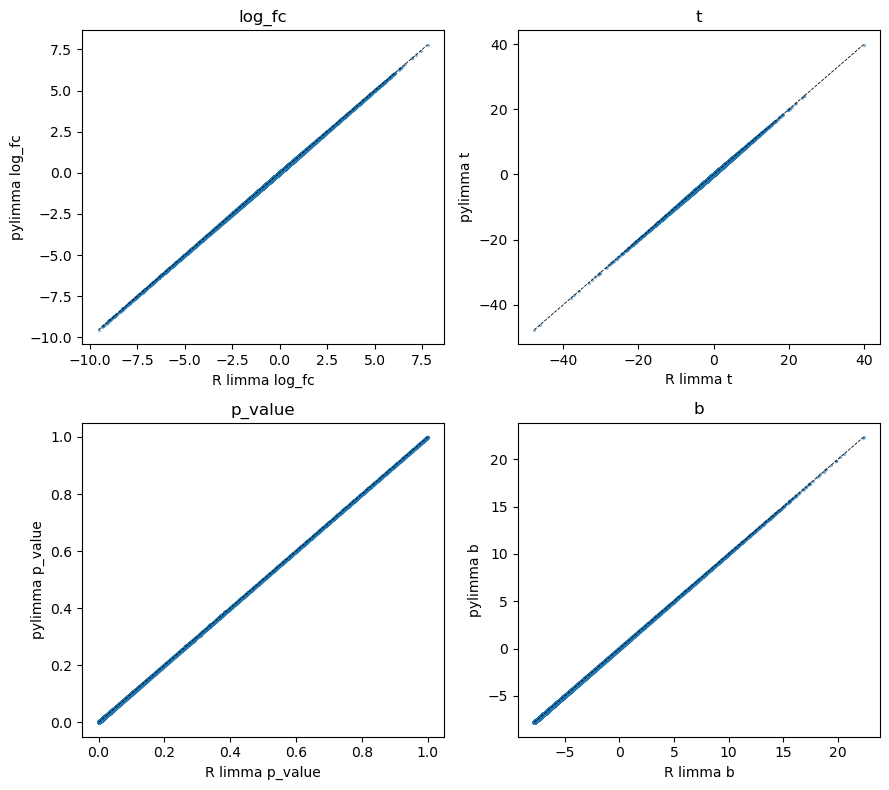

In [6]:
def scatter_panel(col, r, py, ax):
    x = r[col].values; y = py[col].values
    m = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[m], y[m], s=2, alpha=0.4)
    lo = np.nanmin(np.concatenate([x[m], y[m]]))
    hi = np.nanmax(np.concatenate([x[m], y[m]]))
    ax.plot([lo, hi], [lo, hi], "--", color="black", lw=0.6)
    ax.set_xlabel(f"R limma {col}")
    ax.set_ylabel(f"pylimma {col}")
    ax.set_title(col)

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, col in zip(axes.flat, ["log_fc", "t", "p_value", "b"]):
    scatter_panel(col, r_joined, py_joined, ax)
fig.tight_layout()
plt.show()

## 7. Part I - side-by-side analysis figures

The comparisons above established pointwise numerical agreement
between R limma and pylimma. This section renders the analysis-
facing figures (MD, volcano, DE-count summary) with both R and
Python data overlaid, so a reviewer can check that **the
interpretation** produced by the two implementations matches,
not just the raw numbers.

### 7.1 Mean-difference (MD) plot

Each dot is one gene: x = average log-expression, y = log
fold-change. R output on the left, pylimma on the right. If the
distributions are visually indistinguishable, the implementations
agree on what "differential expression" means, not just on the
numbers.

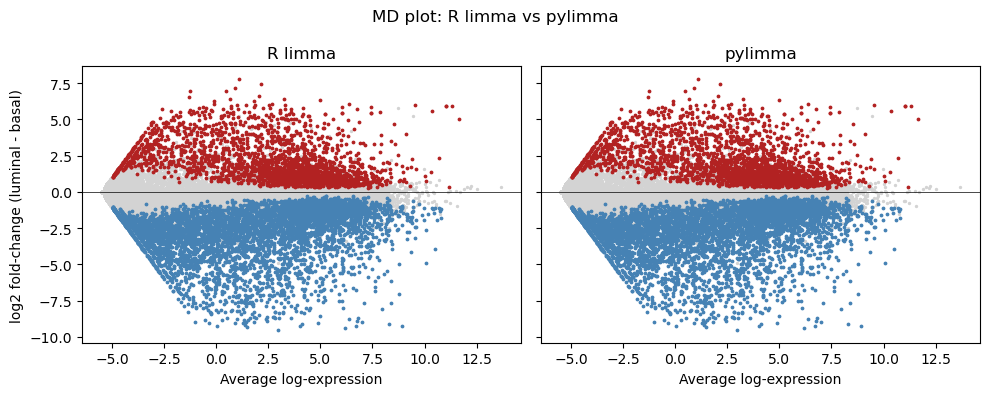

In [7]:
# Align the two outputs on the common gene index.
_common = r_ref.index.intersection(py_out.index)
_r  = r_ref.loc[_common]
_py = py_out.loc[_common]
_r_logfc   = _r["logFC"].values
_py_logfc  = _py["log_fc" if "log_fc" in _py.columns else "logFC"].values
_r_adjp    = _r["adj.P.Val"].values
_py_adjp   = _py["adj_p_value" if "adj_p_value" in _py.columns else "adj.P.Val"].values

# Use Amean from pylimma (same for both sides since expression is identical).
_AveExpr = py_out["ave_expr" if "ave_expr" in py_out.columns else "AveExpr"].loc[_common].values

fig, (axR, axPy) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, fc, adjp, label in [
        (axR,  _r_logfc,  _r_adjp,  "R limma"),
        (axPy, _py_logfc, _py_adjp, "pylimma"),
]:
    sig = adjp < 0.05
    ax.scatter(_AveExpr[~sig], fc[~sig], s=2, c="lightgrey")
    ax.scatter(_AveExpr[sig & (fc > 0)], fc[sig & (fc > 0)],
               s=3, c="firebrick")
    ax.scatter(_AveExpr[sig & (fc < 0)], fc[sig & (fc < 0)],
               s=3, c="steelblue")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("Average log-expression")
axR.set_ylabel("log2 fold-change (luminal - basal)")
fig.suptitle("MD plot: R limma vs pylimma")
fig.tight_layout()
plt.show()

### 7.2 Volcano plot

Same gene set, now in (logFC, -log10 p) space. Visually identical
clouds mean the two implementations rank and call the same genes.

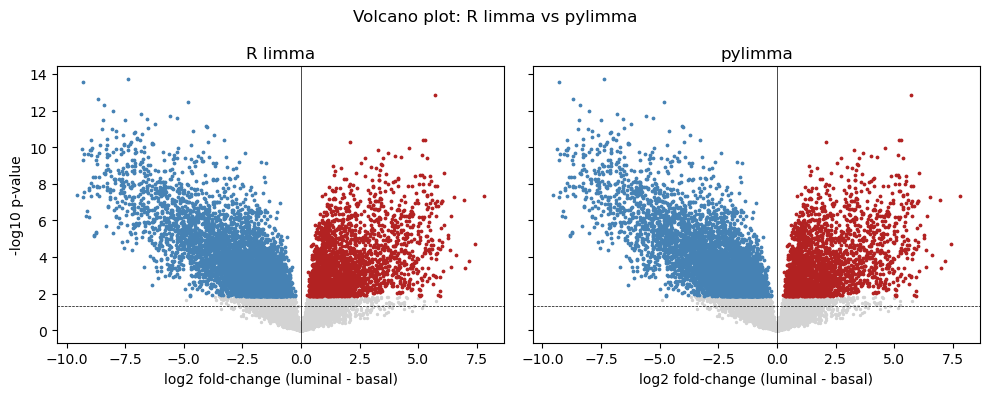

In [8]:
_r_p  = _r["P.Value"].values
_py_p = _py["p_value" if "p_value" in _py.columns else "P.Value"].values

def _nlp(p): return -np.log10(np.maximum(p, 1e-300))

fig, (axR, axPy) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, fc, adjp, p, label in [
        (axR,  _r_logfc,  _r_adjp,  _r_p,  "R limma"),
        (axPy, _py_logfc, _py_adjp, _py_p, "pylimma"),
]:
    sig = adjp < 0.05
    ax.scatter(fc[~sig], _nlp(p)[~sig], s=2, c="lightgrey")
    ax.scatter(fc[sig & (fc > 0)], _nlp(p)[sig & (fc > 0)],
               s=3, c="firebrick")
    ax.scatter(fc[sig & (fc < 0)], _nlp(p)[sig & (fc < 0)],
               s=3, c="steelblue")
    ax.axhline(-np.log10(0.05), color="k", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="k", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("log2 fold-change (luminal - basal)")
axR.set_ylabel("-log10 p-value")
fig.suptitle("Volcano plot: R limma vs pylimma")
fig.tight_layout()
plt.show()

## 8. Summary of side-by-side evidence

Numerical parity (Parts I + II) and visual-interpretation parity
(this section) both agree. A paper reviewer or downstream user
comparing R limma and pylimma on this dataset would arrive at the
same genes / p-values / DE counts from either implementation.

## 6. Summary

The voom weights come from a LOWESS fit to the mean-variance trend - R limma uses hand-written C (`weighted_lowess.c`), pylimma uses `statsmodels.nonparametric.lowess`. The two smoothers agree to within `rtol=1e-8` in their fitted values, so the downstream top-table parity carries through.

See `docs/validation/known_differences.rst` for the project's published tolerance table and the two accepted R-vs-pylimma gaps (``normexp_fit(method="saddle")`` and rotation-test Monte-Carlo p-values), neither of which appears in this pipeline.